In [5]:
!pip install torch_geometric

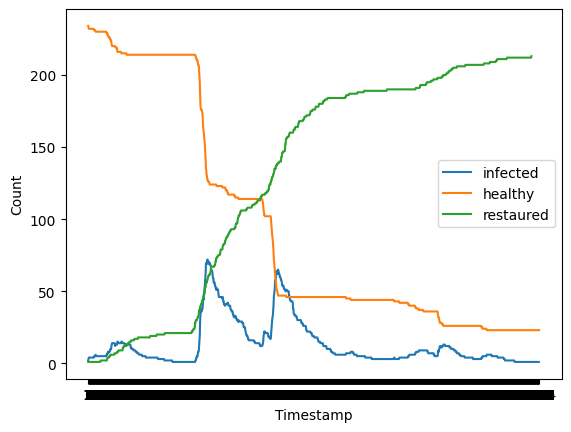

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df = pd.read_csv('combined_state_matrix.csv')

infected = []
restaured = []
healthy = []
for idx,row in df.iterrows():
  uniques = np.unique(row[:],return_counts=True)
  if 0 in uniques[0]: ## healthy
    healthy.append(uniques[1][list(uniques[0]).index(0)])
  if 1 in uniques[0]: ## infected
    infected.append(uniques[1][list(uniques[0]).index(1)])
  if 2 in uniques[0]: ## restaured
    restaured.append(uniques[1][list(uniques[0]).index(2)])

plt.xticks(np.arange(len(infected)))
plt.xlabel("Timestamp")
plt.ylabel("Count")
plt.plot(infected,label="infected")
plt.plot(healthy,label="healthy")
plt.plot(restaured,label="restaured")
plt.legend()
plt.show()

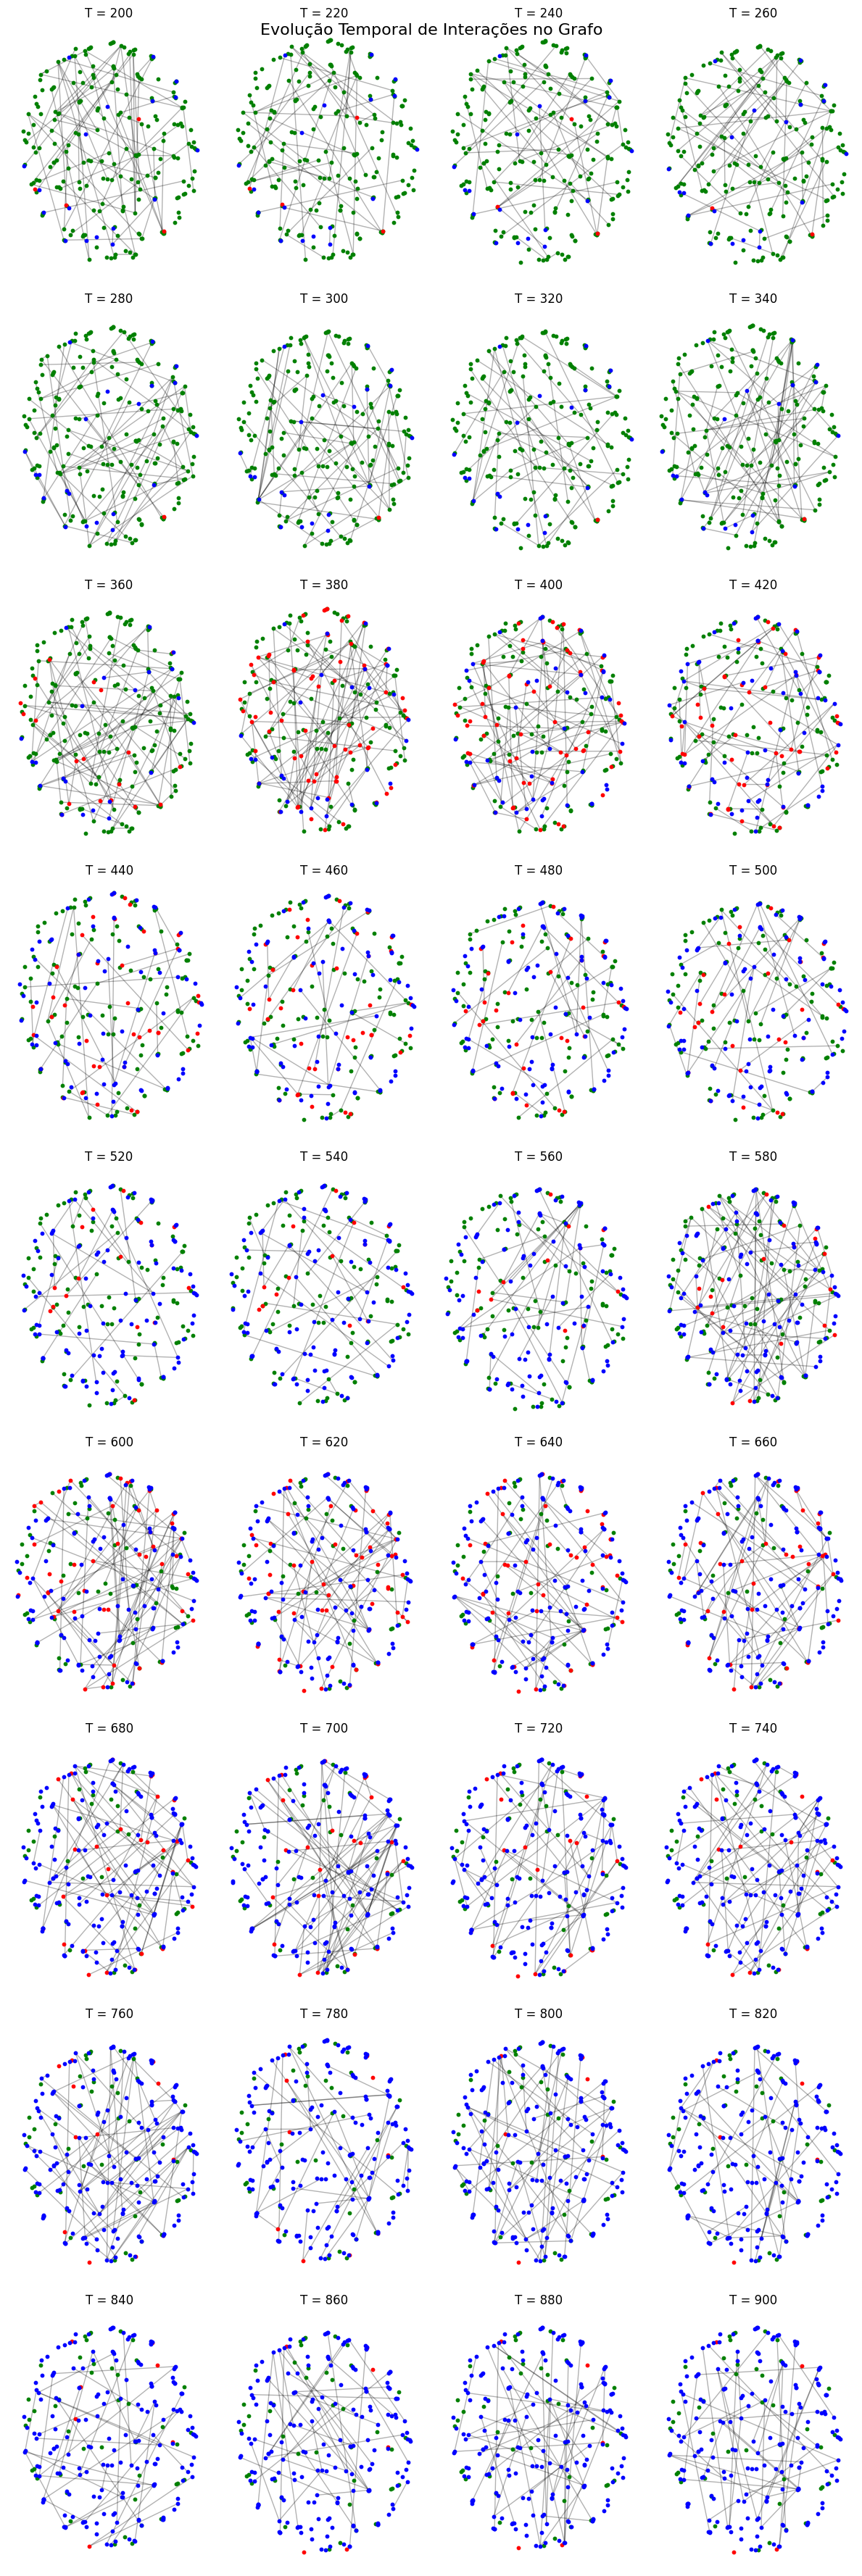

In [7]:
import networkx as nx
import pandas as pd

#csvfile = "https://raw.githubusercontent.com/mpferreira003/SME0130-RedesComplexas/refs/heads/SIR/dataset/socialInteraction.dat"
csvfile = 'temporal_graph.csv'
df_nodes = pd.read_csv(csvfile)


def gen_graph(df: pd.DataFrame, timestamp:int, directed: bool = False) -> nx.Graph:
    G = nx.DiGraph() if directed else nx.Graph()
    max_idx = int(df_nodes[['source','target']].max().max())
    G.add_nodes_from(range(max_idx+1))
    df_filtered = df_nodes[df_nodes['timestamp']==timestamp]

    edges = list(zip(df_filtered['source'], df_filtered['target']))
    G.add_edges_from(edges)
    return G


timestamp_offset = 200
timestamp_add = 20
n_timestamps = 36
maxaxinrow = 4

n_columns = maxaxinrow
n_rows = n_timestamps//maxaxinrow + (1 if n_timestamps%n_columns>0 else 0)
fig, axes = plt.subplots(n_rows, n_columns, figsize=(3*n_columns, 4*n_rows))

complete_graph = nx.complete_graph(len(df.columns))
pos = nx.spring_layout(complete_graph, seed=42)

for iter,timestamp in enumerate(range(timestamp_offset,timestamp_offset+n_timestamps*timestamp_add,timestamp_add)):

    ax_i = iter % maxaxinrow
    ax_j = iter // maxaxinrow
    ax = axes[ax_j, ax_i] if n_rows > 1 else axes[ax_i]

    G = gen_graph(df_nodes,timestamp)

    data_timestamp = df.iloc[timestamp]
    healthy_idx   = np.where(data_timestamp==0)[0].astype(int)

    nx.draw_networkx_nodes(G, pos, node_size=10, ax=ax,nodelist=healthy_idx,node_color='green')

    infected_idx  = np.where(data_timestamp==1)[0].astype(int)
    nx.draw_networkx_nodes(G, pos, node_size=10, ax=ax,nodelist=infected_idx,node_color='red')

    restaured_idx = np.where(data_timestamp==2)[0].astype(int)
    nx.draw_networkx_nodes(G, pos, node_size=10, ax=ax,nodelist=restaured_idx,node_color='blue')

    nx.draw_networkx_edges(G, pos, alpha=0.3, ax=ax)
    ax.set_title(f"T = {timestamp}")
    ax.axis('off')

plt.suptitle('Evolução Temporal de Interações no Grafo', fontsize=16)
plt.tight_layout()
plt.show()

## Fazendo a T-GCN

A GCNConv do Pytorch já faz explicado em: [wikipedia + paper](https://en.wikipedia.org/wiki/Graph_neural_network?#Graph_convolutional_network) e na documentação do [PyTorch](https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.nn.conv.GCNConv.html#torch_geometric.nn.conv.GCNConv), a camada de GCNConv já realiza uma etapa ...

In [20]:
def get_data(timestamp:int|list[int]):
  if isinstance(timestamp,list):
    return [get_data(t) for t in timestamp]
  filtered_df = df_nodes[df_nodes['timestamp']==timestamp]
  sources = filtered_df['source'].to_list()
  targets = filtered_df['target'].to_list()
  edge_list = list(zip(sources,targets))
  node_states = df.iloc[timestamp].to_numpy().astype(int)
  num_nodes = len(node_states)
  return edge_list, node_states, num_nodes

In [9]:
import torch
import torch.nn.functional as F
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import GCNConv

# --- 1. Dados de exemplo (substitua pelos seus) ---
# Supondo que você já tenha:
#   edge_list: lista de tuplas (u,v)
#   node_states: np.array de forma (N,) com valores em {0,1,2}
#   num_nodes: número de nós N

edge_list, node_states, num_nodes = get_data(200)

# 1.1 montando edge_index (2 x E)
edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()

# 1.2 features one-hot S/I/R
#    x.shape = [N, 3]
x = torch.zeros((num_nodes, 3), dtype=torch.float)
print("node_states: ",node_states)
print("num_nodes: ",num_nodes)
x[torch.arange(num_nodes), torch.from_numpy(node_states)] = 1.0

# 1.3 labels
y = torch.from_numpy(node_states).long()  # shape [N]

# 1.4 máscaras de treino/teste (exemplo aleatório 80/20)
perm = torch.randperm(num_nodes)
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask  = torch.zeros(num_nodes, dtype=torch.bool)
train_mask[perm[:int(0.8 * num_nodes)]] = True
test_mask [perm[int(0.8 * num_nodes):]] = True

# 1.5 criar objeto Data do PyG
data = Data(x=x, edge_index=edge_index, y=y,
            train_mask=train_mask, test_mask=test_mask)

# Se houvesse vários grafos (por ex. uma lista DataList),
# usaríamos DataLoader; para um único grafo basta trabalhar diretamente.

# --- 2. Definição do modelo GCN ---
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        # Camada 1 + ReLU
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        # Camada 2 (logits)
        x = self.conv2(x, edge_index)
        return x

# --- 3. Instância, otimizador e loss ---
model = GCN(in_channels=3, hidden_channels=16, out_channels=3)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = torch.nn.CrossEntropyLoss()

# --- 4. Loop de treinamento ---
def train():
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)          # [N, 3]
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

# --- 5. Avaliação ---
def test(mask):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        pred = out.argmax(dim=1)
        correct = (pred[mask] == data.y[mask]).sum().item()
        return correct / mask.sum().item()

# --- 6. Executar ---
for epoch in range(1, 201):
    loss = train()
    if epoch % 20 == 0:
        train_acc = test(data.train_mask)
        test_acc  = test(data.test_mask)
        print(f"Epoch {epoch:03d} | Loss {loss:.4f} | "
              f"Train Acc {train_acc:.4f} | Test Acc {test_acc:.4f}")


node_states:  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 1 2 2 1 0 2 2 1 2 2 0 2 2 0 0 2 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0
 0 0 0 0 2 0 0 0 0 2 0 2 0 0 2 0 0 0 0 0 0 0 2 0 1 0 2 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
num_nodes:  236
Epoch 020 | Loss 0.2662 | Train Acc 0.9149 | Test Acc 0.8958
Epoch 040 | Loss 0.0495 | Train Acc 1.0000 | Test Acc 1.0000
Epoch 060 | Loss 0.0145 | Train Acc 1.0000 | Test Acc 1.0000
Epoch 080 | Loss 0.0071 | Train Acc 1.0000 | Test Acc 1.0000
Epoch 100 | Loss 0.0045 | Train Acc 1.0000 | Test Acc 1.0000
Epoch 120 | Loss 0.0032 | Train Acc 1.0000 | Test Acc 1.0000
Epoch 140 | Loss 0.0024 | Train Acc 1.0000 | Test Acc 1.0000
Epoch 160 | Loss 0.0019 | Train Acc 1.0000 | Test Acc 1.0000
Ep

In [10]:
import random
## Fazendo para vários timestamps
timestamps = df_nodes['timestamp'].unique()

def compute_class_weights(y: torch.Tensor, num_classes: int = 3) -> torch.Tensor:
    """
    Compute dynamic class weights inversely proportional to class frequencies in y.
    y: tensor of labels shape [N]
    returns: weight tensor shape [num_classes]
    """
    counts = torch.bincount(y, minlength=num_classes).float()
    total = y.size(0)
    # avoid division by zero
    counts[counts == 0] = 1.0
    weights = total / (counts * num_classes)
    return weights

# --- Model, optimizer defined once ---
model = GCN(in_channels=3, hidden_channels=16, out_channels=3)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Remove global criterion; we'll create per-batch

def train(data: Data):
    model.train()
    optimizer.zero_grad()
    # compute dynamic weights based on training labels
    y_train = data.y[data.train_mask]
    class_weights = compute_class_weights(y_train, num_classes=3).to(data.x.device)
    criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

    out = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

def prepare_data(timestamp:int,set_node_states=None):
  edge_list, node_states, num_nodes = get_data(timestamp)
  try:
    next_edge_list, next_node_states, next_num_nodes = get_data(timestamp+1)
  except:
    next_edge_list = edge_list
    next_node_states = node_states
    next_num_nodes = num_nodes

  ## usado para fazer predições
  if set_node_states is not None:
    node_states = set_node_states

  edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
  x = torch.zeros((num_nodes, 3), dtype=torch.float)
  x[torch.arange(num_nodes), torch.from_numpy(node_states)] = 1.0
  y = torch.from_numpy(next_node_states).long()


  perm = torch.randperm(num_nodes)
  train_mask = torch.zeros(num_nodes, dtype=torch.bool)
  test_mask  = torch.zeros(num_nodes, dtype=torch.bool)
  train_mask[perm[:int(0.8 * num_nodes)]] = True
  test_mask [perm[int(0.8 * num_nodes):]] = True

  data = Data(x=x, edge_index=edge_index, y=y,
              train_mask=train_mask, test_mask=test_mask)
  return data




## Loop principal -----------------------------
# data_per_timestamp = []
# for timestamp in timestamps[:20]:
#   data = prepare_data(timestamp)
#   data_per_timestamp.append(data)

for epoch in range(1, 1000):
  timestamp = random.randint(0,1400)
  data = prepare_data(timestamp)
  loss = train(data)
  if epoch % 20 == 0:
      train_acc = test(data.train_mask)
      test_acc  = test(data.test_mask)
      print(f"Timestamp: {timestamp:2} Epoch {epoch:03d} | Loss {loss:.4f} | "
            f"Train Acc {train_acc:.4f} | Test Acc {test_acc:.4f}")

Timestamp: 1393 Epoch 020 | Loss 0.3312 | Train Acc 0.9894 | Test Acc 1.0000
Timestamp: 1281 Epoch 040 | Loss 0.1808 | Train Acc 0.9840 | Test Acc 1.0000
Timestamp: 361 Epoch 060 | Loss 0.3896 | Train Acc 0.9574 | Test Acc 0.8542
Timestamp: 965 Epoch 080 | Loss 0.0313 | Train Acc 1.0000 | Test Acc 0.9792
Timestamp: 75 Epoch 100 | Loss 0.1893 | Train Acc 0.9947 | Test Acc 1.0000
Timestamp: 428 Epoch 120 | Loss 0.1353 | Train Acc 0.9681 | Test Acc 1.0000
Timestamp: 772 Epoch 140 | Loss 0.1094 | Train Acc 0.9840 | Test Acc 1.0000
Timestamp: 859 Epoch 160 | Loss 0.1345 | Train Acc 0.9840 | Test Acc 0.9792
Timestamp: 1075 Epoch 180 | Loss 0.0575 | Train Acc 0.9894 | Test Acc 0.9792
Timestamp: 1116 Epoch 200 | Loss 0.0678 | Train Acc 0.9787 | Test Acc 0.9792
Timestamp: 103 Epoch 220 | Loss 0.0308 | Train Acc 1.0000 | Test Acc 1.0000
Timestamp: 10 Epoch 240 | Loss 0.0144 | Train Acc 1.0000 | Test Acc 1.0000
Timestamp: 857 Epoch 260 | Loss 0.0384 | Train Acc 0.9947 | Test Acc 0.9375
Timestamp:

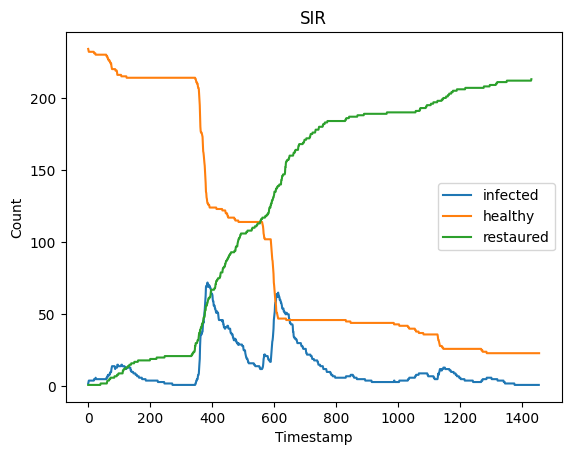

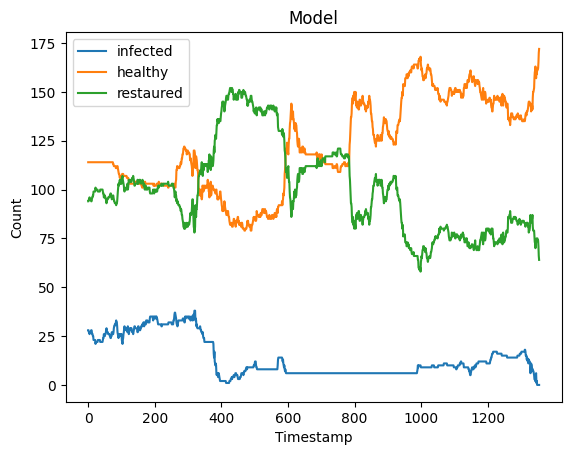

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## ---------------------- plotando o real

infected = []
restaured = []
healthy = []
for idx,row in df.iterrows():
  uniques = np.unique(row[:],return_counts=True)
  if 0 in uniques[0]: ## healthy
    healthy.append(uniques[1][list(uniques[0]).index(0)])
  if 1 in uniques[0]: ## infected
    infected.append(uniques[1][list(uniques[0]).index(1)])
  if 2 in uniques[0]: ## restaured
    restaured.append(uniques[1][list(uniques[0]).index(2)])

plt.title("SIR")
plt.xticks(np.arange(0,len(infected),200))
plt.xlabel("Timestamp")
plt.ylabel("Count")
plt.plot(infected,label="infected")
plt.plot(healthy,label="healthy")
plt.plot(restaured,label="restaured")
plt.legend()
plt.show()


## ---------------------- usando modelo
infected = []
restaured = []
healthy = []

node_states = df.iloc[500].to_numpy().astype(int)
timestamps = df_nodes['timestamp'].unique()
for timestamp in timestamps[:-200]:
  data = prepare_data(timestamp,set_node_states=node_states)
  out = model(data.x, data.edge_index)
  labels = np.argmax(out.detach().numpy(),axis=1)
  node_states = labels

  uniques = np.unique(node_states,return_counts=True)
  if 0 in uniques[0]: ## healthy
    healthy.append(uniques[1][list(uniques[0]).index(0)])
  else:
    healthy.append(0)
  if 1 in uniques[0]: ## infected
    infected.append(uniques[1][list(uniques[0]).index(1)])
  else:
    infected.append(0)
  if 2 in uniques[0]: ## restaured
    restaured.append(uniques[1][list(uniques[0]).index(2)])
  else:
    restaured.append(0)

plt.title("Model")
plt.xticks(np.arange(0,len(infected),200))
plt.xlabel("Timestamp")
plt.ylabel("Count")
plt.plot(infected,label="infected")
plt.plot(healthy,label="healthy")
plt.plot(restaured,label="restaured")
plt.legend()
plt.show()

## Usando TGCN

In [59]:
import random
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

# --- Funções auxiliares: get_data, prepare_data e test ---
# Suponha que get_data(timestamp) retorna edge_list, node_states, num_nodes

hidden_feats = 4


def prepare_data(timestamp: int, set_node_states=None):
    # print("timestamp: ",timestamp)
    edge_list, node_states, num_nodes = get_data(timestamp)
    # Prévê estado no próximo timestamp
    try:
        _, next_node_states, _ = get_data(timestamp + 1)
    except:
        next_node_states = node_states

    if set_node_states is not None:
        node_states = set_node_states

    edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
    x = torch.zeros((num_nodes, 3), dtype=torch.float)
    x[torch.arange(num_nodes), torch.from_numpy(node_states)] = 1.0
    y = torch.from_numpy(next_node_states).long()

    perm = torch.randperm(num_nodes)
    train_mask = torch.zeros(num_nodes, dtype=torch.bool)
    test_mask = torch.zeros(num_nodes, dtype=torch.bool)
    split = int(0.8 * num_nodes)
    train_mask[perm[:split]] = True
    test_mask[perm[split:]] = True

    return Data(x=x, edge_index=edge_index, y=y,
                train_mask=train_mask, test_mask=test_mask)

# Test function
def test_model(data: Data):
    model.eval()
    with torch.no_grad():
        out = model([data.x for _ in range(window_size)], [data.edge_index for _ in range(window_size)])
        pred = out.argmax(dim=1)
        correct = (pred[data.test_mask] == data.y[data.test_mask]).sum().item()
        return correct / data.test_mask.sum().item()

# --- 1. Definição do bloco T-GCNCell e modelo TGCN ---
def compute_class_weights(y: torch.Tensor, num_classes: int = 3) -> torch.Tensor:
    counts = torch.bincount(y, minlength=num_classes).float()
    total = y.size(0)
    counts[counts == 0] = 1.0
    return total / (counts * num_classes)

class TGCNCell(torch.nn.Module):
    def __init__(self, in_feats, hidden_feats):
        super().__init__()
        self.gc = GCNConv(in_feats, hidden_feats)
        self.gru = torch.nn.GRUCell(hidden_feats, hidden_feats)

    def forward(self, x_t, edge_index, h_prev):
        h_space = F.relu(self.gc(x_t, edge_index))
        return self.gru(h_space, h_prev)

class TGCN(torch.nn.Module):
    def __init__(self, node_feats, hidden_feats, out_feats, window_size):
        super().__init__()
        self.T = window_size
        self.cell = TGCNCell(node_feats, hidden_feats)
        self.proj = torch.nn.Linear(hidden_feats, out_feats)

    def forward(self, x_seq, edge_seq):
        N = x_seq[0].size(0)
        h = torch.zeros(N, self.cell.gru.hidden_size, device=x_seq[0].device)
        for t in range(self.T):
            h = self.cell(x_seq[t], edge_seq[t], h)
        return self.proj(h)

# --- 2. Instância, otimizador ---
window_size = 100
model_tgcn = TGCN(node_feats=3, hidden_feats=16, out_feats=3, window_size=window_size)
optimizer = torch.optim.Adam(model_tgcn.parameters(), lr=0.01)

# --- 3. Função de treino em sequência ---
# --- Função de treino sequencial com teacher forcing ---
def train_sequence(start_idx: int, timestamps: list, window_size: int, teacher_p: float):
    """
    Treina o T-GCN em uma janela de window_size+1 passos conforme teacher forcing.
    """
    global out
    # Seleciona timestamps da janela
    ts_window = timestamps[start_idx : start_idx + window_size + 1]
    # Prepara sequência de Data
    data_seq = [prepare_data(ts) for ts in ts_window]
    # Inicializa estado oculto h como zeros
    num_nodes = data_seq[0].x.size(0)
    hidden_dim = model_tgcn.cell.gru.hidden_size
    h = torch.zeros(num_nodes, hidden_dim, device=device)

    model_tgcn.train()
    optimizer.zero_grad()
    loss = 0.0

    # Itera sobre a janela temporal
    for k in range(window_size):
        x_k = data_seq[k].x.to(device)
        e_k = data_seq[k].edge_index.to(device)
        h = model_tgcn.cell(x_k, e_k, h)  # atualização espacial + temporal
        # Pré-cálculo da perda no último passo antes do target
        if k == window_size - 1:
            out = model_tgcn.proj(h)
            y_true = data_seq[-1].y.to(device)
            mask = data_seq[-1].train_mask.to(device)
            weights = compute_class_weights(y_true[mask]).to(device)
            criterion = torch.nn.CrossEntropyLoss(weight=weights)
            loss = criterion(out[mask], y_true[mask])
        # Teacher forcing mix
        if random.random() < teacher_p:
            next_states = data_seq[k+1].y
        else:
            next_states = out.argmax(dim=1).cpu()
        # Atualiza x do próximo Data
        X_next = torch.zeros_like(data_seq[k+1].x)
        X_next[torch.arange(num_nodes), next_states] = 1.0
        data_seq[k+1].x = X_next

    loss.backward()
    optimizer.step()
    return loss.item()

In [ ]:
# --- 4. Loop de treinamento com mapeamento de timestamps ---
# Obter lista ordenada de timestamps disponíveis
timestamps = np.arange(len(df)) #sorted(df_nodes['timestamp'].unique())
max_start = len(timestamps) - window_size - 1
num_epochs = 500
initial_teacher_p = 0.4
final_teacher_p = 0.1

for epoch in range(1, num_epochs + 1):
    start_idx = random.randint(0, max_start)
    # decaimento linear de teacher forcing
    tf_p = initial_teacher_p - (epoch / num_epochs) * (initial_teacher_p - final_teacher_p)
    loss = train_sequence(start_idx, timestamps, window_size, tf_p)
    if epoch % 50 == 0:
        print(f"Epoch {epoch:03d} | Loss {loss:.4f} | TeacherP {tf_p:.2f}")

Epoch 050 | Loss 0.3587 | TeacherP 0.37


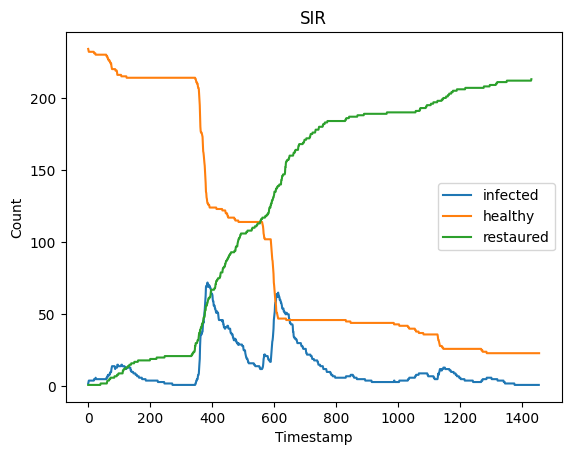

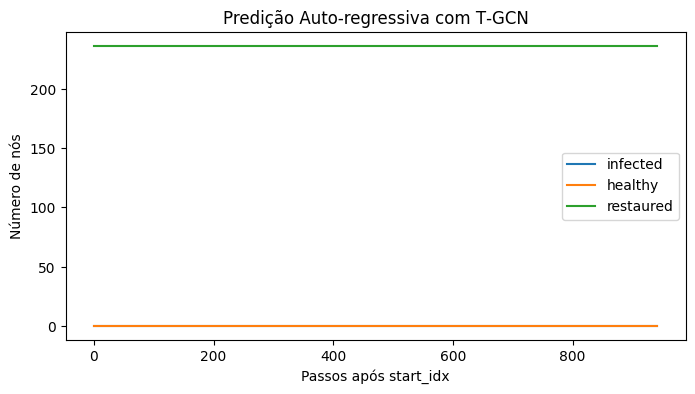

In [58]:
import matplotlib.pyplot as plt
from collections import deque
import pandas as pd
import numpy as np
import torch

## ---------------------- plotando o real

infected = []
restaured = []
healthy = []
for idx,row in df.iterrows():
  uniques = np.unique(row[:],return_counts=True)
  if 0 in uniques[0]: ## healthy
    healthy.append(uniques[1][list(uniques[0]).index(0)])
  if 1 in uniques[0]: ## infected
    infected.append(uniques[1][list(uniques[0]).index(1)])
  if 2 in uniques[0]: ## restaured
    restaured.append(uniques[1][list(uniques[0]).index(2)])

plt.title("SIR")
plt.xticks(np.arange(0,len(infected),200))
plt.xlabel("Timestamp")
plt.ylabel("Count")
plt.plot(infected,label="infected")
plt.plot(healthy,label="healthy")
plt.plot(restaured,label="restaured")
plt.legend()
plt.show()


## ---------------------- usando modelo

# janela do T-GCN
t = model.T
timestamps = np.arange(len(df)-10)

# índice inicial (exemplo)
start_idx = 500
assert start_idx + t < len(timestamps), "Janela inicial ultrapassa limites."

# montar a sequência inicial de Data para os t primeiros passos
device = next(model.parameters()).device
data_sequence = deque(
    prepare_data(timestamps[i]).to(device)
    for i in range(start_idx, start_idx + t)
)

infected = []
healthy  = []
restaured = []

# inferência auto‐regressiva do passo t+0 até o final
for ts in timestamps[start_idx + t:]:
    # preparar entradas do modelo
    x_seq     = [d.x for d in data_sequence]
    edge_seq  = [d.edge_index for d in data_sequence]

    # forward do T‑GCN
    model.eval()
    with torch.no_grad():
        out = model(x_seq, edge_seq)             # [N, 3]
    labels = out.argmax(dim=1).cpu().numpy()     # rótulos previstos

    # contar cada classe
    uniques, counts = np.unique(labels, return_counts=True)
    healthy.append(  counts[uniques.tolist().index(0)] if 0 in uniques else 0 )
    infected.append( counts[uniques.tolist().index(1)] if 1 in uniques else 0 )
    restaured.append(counts[uniques.tolist().index(2)] if 2 in uniques else 0 )

    # montar o próximo Data usando a predição como estado inicial
    next_data = prepare_data(ts, set_node_states=labels).to(device)

    # deslizar a janela
    data_sequence.popleft()
    data_sequence.append(next_data)

# plot das curvas
plt.figure(figsize=(8,4))
plt.title("Predição Auto‐regressiva com T‑GCN")
plt.xlabel("Passos após start_idx")
plt.ylabel("Número de nós")
steps = range(len(infected))
plt.plot(steps, infected,   label="infected")
plt.plot(steps, healthy,    label="healthy")
plt.plot(steps, restaured,  label="restaured")
plt.legend()
plt.show()


## Estudo
[paper](https://arxiv.org/pdf/1811.05320v3)